In [2]:
import os
os.chdir(r'C:\Users\66959\Desktop\stats\data')
os.getcwd()

'C:\\Users\\66959\\Desktop\\stats\\data'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
orig_df1 = pd.read_csv('worldbank_gender_2021.csv')
orig_df2 = pd.read_excel('countries_regions.xlsx')

In [5]:
orig_df = pd.merge(orig_df1, orig_df2, left_on='Country Name', right_on='CountryName')

In [6]:
orig_df.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",Gender Ratio Class,CountryName,Region,ThirdWorld
0,Afghanistan,2021,6.51,58.74,33.60,12.00,2099.0,125.67,5.20,114.32,...,12.79,NaN,NaN,NaN,NaN,NaN,1.0,Afghanistan,South Asia,Yes
1,Albania,2021,16.54,41.47,18.36,21.89,5144.7,114.68,NaN,104.92,...,15.96,NaN,NaN,NaN,NaN,NaN,1.0,Albania,Eastern Europe,No
2,Algeria,2021,NaN,17.35,11.23,3.16,1433.7,108.76,20.68,104.83,...,1.61,NaN,NaN,NaN,NaN,NaN,1.0,Algeria,Africa,No
3,American Samoa,2021,NaN,14.50,NaN,4.85,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa,Australia and Oceanea,No
4,Andorra,2021,NaN,39.91,0.53,1.59,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra,Western Europe,No


In [7]:
orig_df = orig_df.drop(columns=['CountryName', 'Country Name', 'Year'])

In [8]:
df = orig_df.copy()

# Train-test split

In [9]:
X = df.drop(columns=["Gender Ratio Class"])
y = df["Gender Ratio Class"]

In [10]:
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)

# Data preprocessing 

## Handling missing values

In [12]:
print((X_train.isna().mean() * 100).to_string())

Agricultural irrigated land (% of total agricultural land)                                                                                      76.870748
Agricultural land (% of land area)                                                                                                               0.680272
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                       7.482993
Arable land (% of land area)                                                                                                                     0.680272
Cereal yield (kg per hectare)                                                                                                                    7.482993
Crop production index (2014-2016 = 100)                                                                                                          2.040816
Fertilizer consumption (kilograms per hectare of arable land)               

In [13]:
print((y_train.isna().mean() * 100))

0.0


In [14]:
threshold = 0.40
missing_ratio = X_train.isna().mean()
drop_cols = missing_ratio[missing_ratio > threshold].index

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [15]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object','category']).columns

In [16]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [17]:
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

X_train[cat_cols] = X_train[cat_cols].fillna(X_train[cat_cols].mode())
X_test[cat_cols] = X_test[cat_cols].fillna(X_train[cat_cols].mode())

In [18]:
y_train = y_train.fillna(y_train.mode().iloc[0])
y_test = y_test.fillna(y_train.mode().iloc[0])

In [19]:
print((X_train.isna().mean() * 100).to_string())

Agricultural land (% of land area)                                                                 0.0
Agriculture, forestry, and fishing, value added (% of GDP)                                         0.0
Arable land (% of land area)                                                                       0.0
Cereal yield (kg per hectare)                                                                      0.0
Crop production index (2014-2016 = 100)                                                            0.0
Fertilizer consumption (kilograms per hectare of arable land)                                      0.0
Food production index (2014-2016 = 100)                                                            0.0
Forest area (% of land area)                                                                       0.0
Forest area (sq. km)                                                                               0.0
Land area (sq. km)                                                       

## Encoding

In [20]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [21]:
X_train.shape

(147, 97)

In [22]:
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=True)
    return df

In [23]:
X_train = onehot_encoder_selected(X_train, cat_cols)
X_test = onehot_encoder_selected(X_test, cat_cols)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [24]:
X_train.shape

(147, 108)

In [25]:
X_test.shape

(37, 108)

## Scaling

In [26]:
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

In [27]:
X_train_scaled, X_test_scaled = scale_standard(X_train, X_test)

# Feature Extraction

## Linear Discriminant Analysis

In [28]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(
    n_components=4
)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

In [29]:
X_train_lda.shape

(147, 4)

In [30]:
lda_loadings = pd.DataFrame(
    lda.scalings_,
    index=X_train.columns,
    columns=[f"LD{i+1}" for i in range(lda.scalings_.shape[1])]
)

lda_loadings.head()

,LD1,LD2,LD3,LD4
Agricultural land (% of land area),-0.016667,-0.034333,-0.782987,-0.649006
"Agriculture, forestry, and fishing, value added (% of GDP)",1.515494,1.086440,0.041437,0.525527
Arable land (% of land area),-0.060356,-0.889390,0.848259,0.323832
Cereal yield (kg per hectare),0.134446,-0.420704,-0.365803,0.010858
Crop production index (2014-2016 = 100),-1.852720,-0.343003,-0.021136,0.832666


In [31]:
lda_loadings.abs().sort_values(by="LD1", ascending=False).head(10)

,LD1,LD2,LD3,LD4
Population ages 0-14 (% of total population),114.924208,659.766589,682.981412,172.605388
Population ages 15-64 (% of total population),77.926440,395.608297,414.071063,101.088812
Population ages 65 and above (% of total population),74.765579,417.896753,434.813844,106.768874
"Life expectancy at birth, total (years)",70.964448,82.367218,55.709154,22.822215
"Life expectancy at birth, male (years)",40.742477,39.371659,28.059790,11.250888
"Life expectancy at birth, female (years)",29.542129,40.751866,23.233083,12.470331
Merchandise exports (current US$),12.098148,16.587741,1.438936,6.203192
Age dependency ratio (% of working-age population),11.395137,0.732891,4.287627,0.166433
Merchandise imports (current US$),8.600402,14.435171,4.260891,4.917317
"Labor force, total",8.118570,27.568715,10.046114,3.997019


In [32]:
# Function to compute performance classification metrics
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [33]:
X_train_lda.shape

(147, 4)

In [34]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,     
    max_depth=5,            
    min_child_weight=1,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=0
)

model.fit(X_train_lda, y_train)
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test_lda)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

[[1 5 1 0 0]
 [2 3 4 1 1]
 [0 1 1 1 3]
 [0 4 0 0 0]
 [1 6 1 1 0]]
0.13513513513513514 0.11015037593984962 0.11645021645021644 0.10713286713286714


## Principal Component Analysis

In [35]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)

In [36]:
n_components = np.argmax(explained_var >= 0.85) + 1
n_components

np.int64(29)

In [37]:
pca = PCA(n_components=n_components, random_state=0)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [38]:
X_train_pca.shape

(147, 29)

In [40]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train.columns,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

pca_loadings.head().sort_values(by="PC1", ascending=False)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29
"Agriculture, forestry, and fishing, value added (% of GDP)",0.160500,0.045564,0.030112,0.020007,0.045509,-0.049857,0.080602,-0.009319,0.004917,-0.113940,...,-0.089232,-0.002413,0.006095,-0.078619,0.126083,-0.140277,0.054204,0.161573,0.080856,-0.001359
Crop production index (2014-2016 = 100),0.079140,0.049499,-0.068050,0.101998,0.055247,-0.011548,0.048281,0.290664,0.074146,-0.020158,...,-0.007644,-0.074352,0.243191,0.101666,-0.058293,0.015769,-0.063394,0.069758,-0.084403,0.057757
Agricultural land (% of land area),0.057386,0.038336,0.077950,-0.146076,0.184953,-0.028360,0.045608,0.264085,0.064736,0.036700,...,-0.071114,0.074246,-0.062810,-0.180695,-0.074661,0.041982,-0.092294,-0.077294,0.000177,0.100324
Arable land (% of land area),0.016113,0.018389,0.133861,-0.161051,0.179874,-0.196044,0.039713,0.155197,-0.137940,-0.044334,...,-0.054451,0.080159,-0.060687,0.056238,0.041829,0.103483,-0.009966,0.037415,0.166073,0.114932
Cereal yield (kg per hectare),-0.093750,-0.007618,-0.057588,-0.008942,-0.026193,-0.060546,0.081582,0.012267,-0.038410,0.025338,...,-0.079494,0.117024,-0.166429,-0.099684,-0.073438,0.018506,-0.287430,-0.002905,0.037176,-0.103488


In [41]:
pca_loadings["PC1"].abs().sort_values(ascending=False).head(10)

Population ages 0-14 (% of total population)                                     0.191988
Birth rate, crude (per 1,000 people)                                             0.190620
Life expectancy at birth, female (years)                                         0.190296
Life expectancy at birth, total (years)                                          0.188937
Life expectancy at birth, male (years)                                           0.185391
Fertility rate, total (births per woman)                                         0.182130
Vulnerable employment, female (% of female employment) (modeled ILO estimate)    0.179366
Vulnerable employment, male (% of male employment) (modeled ILO estimate)        0.177458
Mortality rate, under-5 (per 1,000 live births)                                  0.176652
Fixed broadband subscriptions (per 100 people)                                   0.176042
Name: PC1, dtype: float64

In [44]:
pca_loadings["PC2"].abs().sort_values(ascending=False).head(10)

Urban population                                          0.267049
GNI, PPP (current international $)                        0.263100
Labor force, total                                        0.262128
Air transport, registered carrier departures worldwide    0.254318
External debt stocks, total (DOD, current US$)            0.253473
GDP (current US$)                                         0.250415
Population, total                                         0.248911
Total reserves (includes gold, current US$)               0.234807
Merchandise exports (current US$)                         0.232020
Merchandise imports (current US$)                         0.226440
Name: PC2, dtype: float64

In [45]:
pca_loadings["PC3"].abs().sort_values(ascending=False).head(10)

Labor force, female (% of total labor force)                                                       0.331634
Population, female (% of total population)                                                         0.266534
Region_Middle East                                                                                 0.262004
Diabetes prevalence (% of population ages 20 to 79)                                                0.248178
Death rate, crude (per 1,000 people)                                                               0.241547
Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)    0.215367
Military expenditure (% of GDP)                                                                    0.195548
Population ages 65 and above (% of total population)                                               0.189571
Annual freshwater withdrawals, total (% of internal resources)                                     0.165363
Industry (including construc

In [46]:
pca_loadings["PC4"].abs().sort_values(ascending=False).head(10)

Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)    0.237888
Gross savings (% of GDP)                                                                           0.211506
Industry (including construction), value added (% of GDP)                                          0.200709
Food production index (2014-2016 = 100)                                                            0.199427
Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)        0.199282
Fuel exports (% of merchandise exports)                                                            0.195644
Livestock production index (2014-2016 = 100)                                                       0.190863
Unemployment, total (% of total labor force) (modeled ILO estimate)                                0.186996
Population, female (% of total population)                                                         0.186435
Exports of goods and service

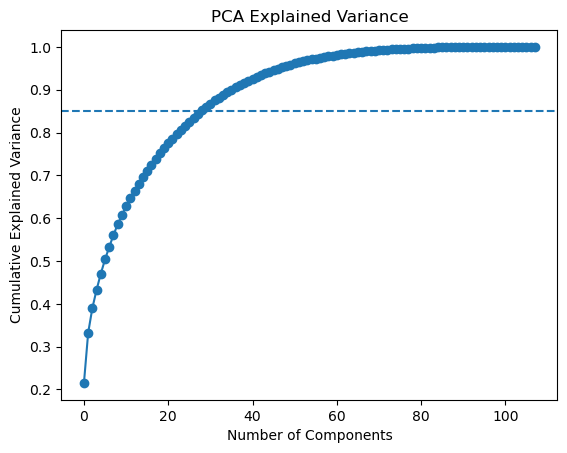

In [42]:
import matplotlib.pyplot as plt

plt.plot(explained_var, marker='o')
plt.axhline(y=0.85, linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


In [43]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,     
    max_depth=5,            
    min_child_weight=1,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=0
)

model.fit(X_train_pca, y_train)
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test_pca)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

[[3 4 0 0 0]
 [4 3 1 1 2]
 [0 1 2 1 2]
 [1 3 0 0 0]
 [1 2 3 0 3]]
0.2972972972972973 0.2652014652014652 0.27359307359307355 0.26666666666666666
